In [1]:
# Install required packages
%pip install torch pandas numpy scikit-learn tqdm matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\vassa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
# =============================================================================
# CONFIGURATION - Choose your prediction target
# =============================================================================

# Available targets:
#   Classification:
#     - 'implementation'          : QUIC implementation (aioquic, nginx, quicgo, quiche)
#     - 'migration_type'          : Type of migration scenario
#     - 'connection_close_type'   : How the connection was closed
#     - 'retry_occurred'          : Binary - whether retry occurred
#     - 'version_negotiation_occurred' : Binary - whether version negotiation occurred
#     - 'path_validation_initiated'    : Binary - whether path validation was initiated
#
#   Regression (set TASK_TYPE = 'regression'):
#     - 'handshake_duration'      : Duration of handshake in ms
#     - 'connection_duration'     : Total connection duration
#     - 'packets_before_migration': Number of packets before migration

TARGET_COLUMN = 'implementation'  # <-- Change this to try different targets
TASK_TYPE = 'classification'      # <-- 'classification' or 'regression'

print(f"Target: {TARGET_COLUMN}")
print(f"Task type: {TASK_TYPE}")

Target: implementation
Task type: classification


## 1. Load and Prepare Data

In [4]:
# Define paths
LOW_LEVEL_PATH = '../../low_level_features/dataset/all_low_level_features_merged.csv'
HIGH_LEVEL_PATH = '../../high_level_features/dataset/all_captures_dataset.csv'

# Load datasets
print("Loading low-level features...")
low_level_df = pd.read_csv(LOW_LEVEL_PATH)
print(f"Low-level data shape: {low_level_df.shape}")

print("\nLoading high-level features...")
high_level_df = pd.read_csv(HIGH_LEVEL_PATH)
print(f"High-level data shape: {high_level_df.shape}")

# Create mapping from capture_id/file_id to target
id_to_target = dict(zip(high_level_df['file_id'], high_level_df[TARGET_COLUMN]))

# Display target info
print(f"\nTarget column: {TARGET_COLUMN}")
if TASK_TYPE == 'classification':
    unique_targets = high_level_df[TARGET_COLUMN].unique()
    print(f"Unique classes: {unique_targets}")
    print(f"Class counts:\n{high_level_df[TARGET_COLUMN].value_counts()}")
    NUM_CLASSES = len(unique_targets)
else:
    print(f"Target statistics:")
    print(high_level_df[TARGET_COLUMN].describe())

Loading low-level features...
Low-level data shape: (261196, 26)

Loading high-level features...
High-level data shape: (11911, 57)

Target column: implementation
Unique classes: ['aioquic' 'nginx' 'quicgo' 'quiche']
Class counts:
quiche     3170
quicgo     2999
nginx      2992
aioquic    2750
Name: implementation, dtype: int64


In [5]:
# Verify mapping - get unique capture_ids that have target labels
# Filter out any NaN values in the target
valid_file_ids = high_level_df[high_level_df[TARGET_COLUMN].notna()]['file_id']
valid_capture_ids = set(low_level_df['capture_id'].unique()) & set(valid_file_ids)
print(f"Valid capture IDs with target labels: {len(valid_capture_ids)}")

# Filter low_level_df to only include sequences with valid target labels
low_level_df = low_level_df[low_level_df['capture_id'].isin(valid_capture_ids)]
print(f"Filtered low-level data shape: {low_level_df.shape}")

Valid capture IDs with target labels: 11911
Filtered low-level data shape: (261196, 26)


## 2. Dataset Class for Sequential Data

In [6]:
class LowLevelSequenceDataset(Dataset):
    """
    Dataset class for loading low-level packet sequences.
    Each sequence represents a QUIC connection capture.
    Supports both classification and regression tasks.
    """
    def __init__(self, low_level_df, id_to_target, capture_ids, task_type='classification', 
                 scaler=None, label_encoder=None, max_seq_len=100):
        """
        Args:
            low_level_df: DataFrame with low-level packet features
            id_to_target: Dict mapping capture_id to target value
            capture_ids: List of capture_ids to include in this dataset
            task_type: 'classification' or 'regression'
            scaler: Pre-fitted scaler (for test set) or None (for train set)
            label_encoder: Pre-fitted LabelEncoder (for test set) or None (for train set)
            max_seq_len: Maximum sequence length (truncate/pad to this length)
        """
        self.low_level_df = low_level_df
        self.id_to_target = id_to_target
        self.capture_ids = capture_ids
        self.max_seq_len = max_seq_len
        self.task_type = task_type
        
        # Features to use (exclude frame_number and capture_id)
        self.feature_columns = [
            'delta_time', 'packet_length', 'packet_direction', 'header_form',
            'count_initial', 'count_0rtt', 'count_handshake', 'count_1rtt',
            'count_retry', 'count_vn', 'count_ack', 'count_padding',
            'count_connection_close', 'count_path_challenge', 'count_path_response',
            'count_new_connection_id', 'count_retire_cid', 'count_ping',
            'count_crypto', 'count_handshake_done', 'http3_stream_count',
            'http3_fin_count', 'stream_length', 'stream_type_count'
        ]
        
        # Handle labels based on task type
        if task_type == 'classification':
            if label_encoder is None:
                self.label_encoder = LabelEncoder()
                all_targets = list(set(id_to_target.values()))
                self.label_encoder.fit(all_targets)
            else:
                self.label_encoder = label_encoder
            self.num_classes = len(self.label_encoder.classes_)
        else:
            # Regression - normalize target values
            self.label_encoder = None
            all_target_values = [id_to_target[cid] for cid in capture_ids]
            self.target_mean = np.mean(all_target_values)
            self.target_std = np.std(all_target_values) + 1e-8  # Avoid division by zero
        
        # Fit or use provided scaler
        if scaler is None:
            self.scaler = MinMaxScaler()
            # Fit scaler on all features for training capture_ids
            train_data = self.low_level_df[self.low_level_df['capture_id'].isin(capture_ids)]
            self.scaler.fit(train_data[self.feature_columns].values)
        else:
            self.scaler = scaler
    
    def __len__(self):
        return len(self.capture_ids)
    
    def __getitem__(self, idx):
        capture_id = self.capture_ids[idx]
        
        # Get sequence for this capture
        sequence_df = self.low_level_df[self.low_level_df['capture_id'] == capture_id]
        sequence_df = sequence_df[self.feature_columns]
        
        # Scale features
        scaled_sequence = self.scaler.transform(sequence_df.values)
        
        # Get label
        target_value = self.id_to_target[capture_id]
        
        if self.task_type == 'classification':
            label = self.label_encoder.transform([target_value])[0]
            label_tensor = torch.LongTensor([label])[0]
        else:
            # Normalize regression target
            normalized_target = (target_value - self.target_mean) / self.target_std
            label_tensor = torch.FloatTensor([normalized_target])[0]
        
        return {
            'sequence': torch.FloatTensor(scaled_sequence),
            'label': label_tensor,
            'capture_id': capture_id
        }

In [7]:
def collate_fn(batch):
    """
    Custom collate function to handle variable-length sequences.
    Pads sequences to the maximum length in the batch.
    """
    sequences = [item['sequence'] for item in batch]
    labels = torch.stack([item['label'] for item in batch])
    
    # Get sequence lengths before padding
    lengths = torch.tensor([len(seq) for seq in sequences])
    
    # Pad sequences
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=0.0)
    
    return {
        'sequence': padded_sequences,
        'label': labels,
        'lengths': lengths
    }

## 3. LSTM Classifier Model

In [8]:
class LSTMClassifier(nn.Module):
    """
    LSTM-based model for packet sequences.
    Supports both classification and regression tasks.
    """
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, num_classes=4, 
                 dropout=0.3, task_type='classification'):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.task_type = task_type
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        # Attention layer for sequence aggregation
        self.attention = nn.Linear(hidden_dim * 2, 1)
        
        # Output head - different for classification vs regression
        if task_type == 'classification':
            self.output_head = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, num_classes)
            )
        else:
            # Regression head outputs single value
            self.output_head = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1)
            )
    
    def forward(self, x, lengths=None):
        """
        Args:
            x: (batch_size, seq_len, input_dim) - padded sequences
            lengths: (batch_size,) - actual sequence lengths
        """
        batch_size = x.shape[0]
        
        # Pack sequences if lengths provided
        if lengths is not None:
            # Sort by length for packing
            lengths_sorted, sort_idx = lengths.sort(descending=True)
            x_sorted = x[sort_idx]
            
            # Pack padded sequence
            packed = nn.utils.rnn.pack_padded_sequence(
                x_sorted, lengths_sorted.cpu(), batch_first=True, enforce_sorted=True
            )
            
            # LSTM forward
            lstm_out, (hn, cn) = self.lstm(packed)
            
            # Unpack
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
            
            # Unsort to original order
            _, unsort_idx = sort_idx.sort()
            lstm_out = lstm_out[unsort_idx]
        else:
            lstm_out, (hn, cn) = self.lstm(x)
        
        # Attention mechanism
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        
        # Output
        output = self.output_head(context)
        
        if self.task_type == 'regression':
            output = output.squeeze(-1)  # Remove last dimension for regression
        
        return output

## 4. Training and Evaluation Functions

In [29]:
def train_epoch(model, dataloader, optimizer, criterion, device, task_type='classification'):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc="Training", leave=False):
        sequences = batch['sequence'].to(device)
        labels = batch['label'].to(device)
        lengths = batch['lengths']
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(sequences, lengths)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        if task_type == 'classification':
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        else:
            # Use detach() before numpy() for tensors with gradients
            all_preds.extend(outputs.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
    
    if task_type == 'classification':
        return total_loss / len(dataloader), correct / total
    else:
        # Return R² score for regression
        from sklearn.metrics import r2_score
        r2 = r2_score(all_labels, all_preds)
        return total_loss / len(dataloader), r2


def evaluate(model, dataloader, criterion, device, task_type='classification'):
    """Evaluate model on dataloader."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            sequences = batch['sequence'].to(device)
            labels = batch['label'].to(device)
            lengths = batch['lengths']
            
            outputs = model(sequences, lengths)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            if task_type == 'classification':
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
            else:
                all_preds.extend(outputs.cpu().numpy())
            
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(dataloader), np.array(all_preds), np.array(all_labels)

In [30]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20, task_type='classification'):
    """Full training loop with validation."""
    best_val_metric = -float('inf')  # Works for both accuracy and R²
    best_model_state = None
    metric_name = 'Acc' if task_type == 'classification' else 'R²'
    history = {'train_loss': [], 'train_metric': [], 'val_loss': [], 'val_metric': []}
    
    for epoch in range(epochs):
        # Train
        train_loss, train_metric = train_epoch(model, train_loader, optimizer, criterion, device, task_type)
        
        # Validate
        val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device, task_type)
        
        if task_type == 'classification':
            val_metric = accuracy_score(val_labels, val_preds)
        else:
            from sklearn.metrics import r2_score
            val_metric = r2_score(val_labels, val_preds)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_metric'].append(train_metric)
        history['val_loss'].append(val_loss)
        history['val_metric'].append(val_metric)
        
        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_loss:.4f}, Train {metric_name}: {train_metric:.4f} - "
              f"Val Loss: {val_loss:.4f}, Val {metric_name}: {val_metric:.4f}")
        
        # Save best model
        if val_metric > best_val_metric:
            best_val_metric = val_metric
            best_model_state = model.state_dict().copy()
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history

## 5. Prepare Train/Test Split

For now, we split the real data in half to establish the methodology.
Later, this can be replaced with synthetic training data for TSTR evaluation.

In [31]:
# Get all capture IDs with their targets
all_capture_ids = list(valid_capture_ids)
all_targets = [id_to_target[cid] for cid in all_capture_ids]

# Split based on task type
if TASK_TYPE == 'classification':
    # Stratified split to maintain class balance
    train_ids, test_ids = train_test_split(
        all_capture_ids, 
        test_size=0.5,  # Split in half for methodology
        stratify=all_targets,
        random_state=42
    )
else:
    # Random split for regression
    train_ids, test_ids = train_test_split(
        all_capture_ids, 
        test_size=0.5,
        random_state=42
    )

print(f"Training samples: {len(train_ids)}")
print(f"Test samples: {len(test_ids)}")

# Check distribution
train_targets = [id_to_target[cid] for cid in train_ids]
test_targets = [id_to_target[cid] for cid in test_ids]

if TASK_TYPE == 'classification':
    print(f"\nTraining class distribution:")
    for t in set(train_targets):
        print(f"  {t}: {train_targets.count(t)}")
    print(f"\nTest class distribution:")
    for t in set(test_targets):
        print(f"  {t}: {test_targets.count(t)}")
else:
    print(f"\nTraining target stats: mean={np.mean(train_targets):.2f}, std={np.std(train_targets):.2f}")
    print(f"Test target stats: mean={np.mean(test_targets):.2f}, std={np.std(test_targets):.2f}")

Training samples: 5955
Test samples: 5956

Training class distribution:
  nginx: 1496
  aioquic: 1375
  quiche: 1585
  quicgo: 1499

Test class distribution:
  quicgo: 1500
  nginx: 1496
  quiche: 1585
  aioquic: 1375


In [12]:
# Create datasets
print("Creating training dataset...")
train_dataset = LowLevelSequenceDataset(
    low_level_df=low_level_df,
    id_to_target=id_to_target,
    capture_ids=train_ids,
    task_type=TASK_TYPE,
    scaler=None,  # Fit new scaler
    label_encoder=None  # Fit new encoder
)

print("Creating test dataset...")
test_dataset = LowLevelSequenceDataset(
    low_level_df=low_level_df,
    id_to_target=id_to_target,
    capture_ids=test_ids,
    task_type=TASK_TYPE,
    scaler=train_dataset.scaler,  # Use same scaler as training
    label_encoder=train_dataset.label_encoder if TASK_TYPE == 'classification' else None
)

print(f"\nNumber of features: {len(train_dataset.feature_columns)}")
print(f"Feature columns: {train_dataset.feature_columns}")
if TASK_TYPE == 'classification':
    print(f"Number of classes: {train_dataset.num_classes}")

Creating training dataset...
Creating test dataset...

Number of features: 24
Feature columns: ['delta_time', 'packet_length', 'packet_direction', 'header_form', 'count_initial', 'count_0rtt', 'count_handshake', 'count_1rtt', 'count_retry', 'count_vn', 'count_ack', 'count_padding', 'count_connection_close', 'count_path_challenge', 'count_path_response', 'count_new_connection_id', 'count_retire_cid', 'count_ping', 'count_crypto', 'count_handshake_done', 'http3_stream_count', 'http3_fin_count', 'stream_length', 'stream_type_count']
Number of classes: 4


In [13]:
# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn,
    num_workers=0
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 187
Test batches: 187


## 6. Initialize and Train Model

In [14]:
# Model hyperparameters
INPUT_DIM = len(train_dataset.feature_columns)  # 24 features
HIDDEN_DIM = 64
NUM_LAYERS = 2
DROPOUT = 0.3
LEARNING_RATE = 0.001
EPOCHS = 15

# Number of classes (only used for classification)
if TASK_TYPE == 'classification':
    NUM_CLASSES = train_dataset.num_classes
else:
    NUM_CLASSES = 1  # Not used for regression

# Initialize model
model = LSTMClassifier(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    task_type=TASK_TYPE
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Task type: {TASK_TYPE}")

LSTMClassifier(
  (lstm): LSTM(24, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (output_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total parameters: 154,053
Task type: classification


In [15]:
# Loss and optimizer
if TASK_TYPE == 'classification':
    criterion = nn.CrossEntropyLoss()
else:
    criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Train the model
print("Starting training...\n")
model, history = train_model(
    model, 
    train_loader, 
    test_loader,  # Using test as validation for now
    optimizer, 
    criterion, 
    device, 
    epochs=EPOCHS,
    task_type=TASK_TYPE
)

Starting training...



Epoch 1/15 - Train Loss: 0.3184, Train Acc: 0.8626 - Val Loss: 0.0055, Val Acc: 0.9990


Epoch 2/15 - Train Loss: 0.0034, Train Acc: 0.9992 - Val Loss: 0.0004, Val Acc: 0.9998


Epoch 3/15 - Train Loss: 0.0007, Train Acc: 0.9998 - Val Loss: 0.0004, Val Acc: 0.9998


Epoch 4/15 - Train Loss: 0.0050, Train Acc: 0.9993 - Val Loss: 0.0004, Val Acc: 0.9998


...

Epoch 11/15 - Train Loss: 0.0003, Train Acc: 1.0000 - Val Loss: 0.0003, Val Acc: 1.0000


Epoch 12/15 - Train Loss: 0.0002, Train Acc: 1.0000 - Val Loss: 0.0003, Val Acc: 1.0000


Epoch 13/15 - Train Loss: 0.0002, Train Acc: 1.0000 - Val Loss: 0.0002, Val Acc: 1.0000


Epoch 14/15 - Train Loss: 0.0002, Train Acc: 1.0000 - Val Loss: 0.0002, Val Acc: 1.0000


Epoch 15/15 - Train Loss: 0.0002, Train Acc: 1.0000 - Val Loss: 0.0002, Val Acc: 1.0000


## 7. Evaluate Results

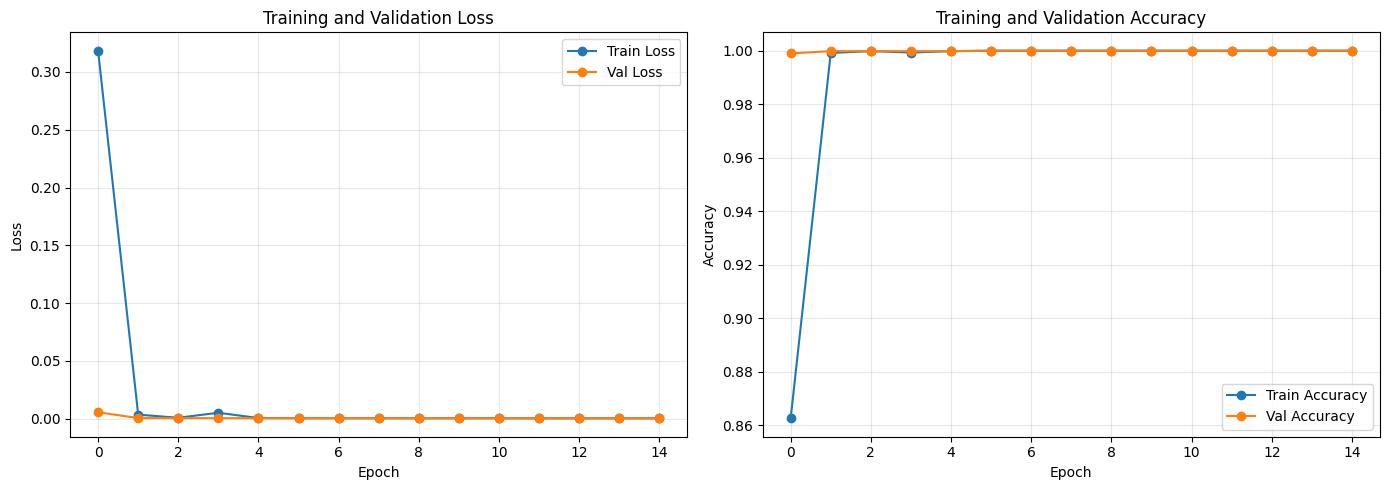

In [16]:
# Plot training history
metric_name = 'Accuracy' if TASK_TYPE == 'classification' else 'R² Score'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Metric plot
axes[1].plot(history['train_metric'], label=f'Train {metric_name}', marker='o')
axes[1].plot(history['val_metric'], label=f'Val {metric_name}', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel(metric_name)
axes[1].set_title(f'Training and Validation {metric_name}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Final evaluation on test set
test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, device, task_type=TASK_TYPE)

print("="*60)
print(f"FINAL EVALUATION RESULTS - {TARGET_COLUMN.upper()}")
print("="*60)

if TASK_TYPE == 'classification':
    # Get class names
    class_names = train_dataset.label_encoder.classes_
    
    print(f"\nTest Accuracy: {accuracy_score(test_labels, test_preds):.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print("\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=class_names, zero_division=0))
else:
    # Regression metrics
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    
    # Denormalize predictions and labels
    preds_denorm = test_preds * train_dataset.target_std + train_dataset.target_mean
    labels_denorm = test_labels * train_dataset.target_std + train_dataset.target_mean
    
    print(f"\nTest R² Score: {r2_score(labels_denorm, preds_denorm):.4f}")
    print(f"Test MAE: {mean_absolute_error(labels_denorm, preds_denorm):.4f}")
    print(f"Test RMSE: {np.sqrt(mean_squared_error(labels_denorm, preds_denorm)):.4f}")
    print(f"Test Loss (normalized MSE): {test_loss:.4f}")

FINAL EVALUATION RESULTS - IMPLEMENTATION

Test Accuracy: 1.0000
Test Loss: 0.0002

Classification Report:
              precision    recall  f1-score   support

     aioquic       1.00      1.00      1.00      1375
       nginx       1.00      1.00      1.00      1496
      quicgo       1.00      1.00      1.00      1500
      quiche       1.00      1.00      1.00      1585

    accuracy                           1.00      5956
   macro avg       1.00      1.00      1.00      5956
weighted avg       1.00      1.00      1.00      5956



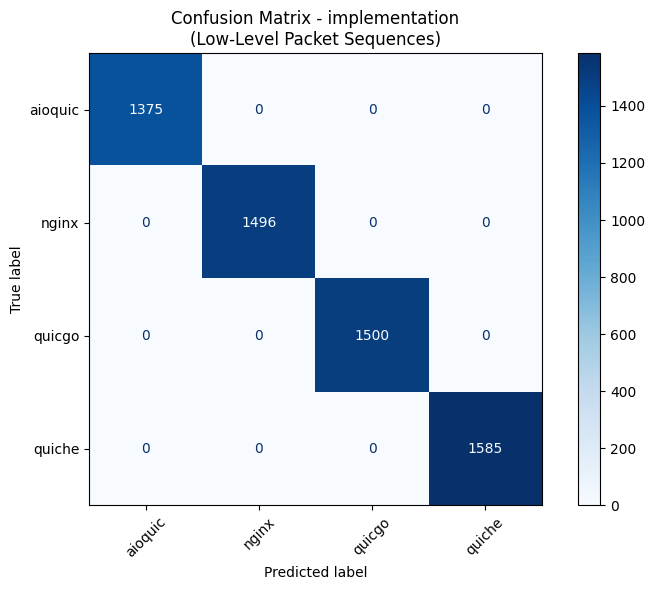

In [18]:
if TASK_TYPE == 'classification':
    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(test_labels, test_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", ax=ax, values_format='d', xticks_rotation=45)
    plt.title(f"Confusion Matrix - {TARGET_COLUMN}\n(Low-Level Packet Sequences)")
    plt.tight_layout()
    plt.show()
else:
    # Scatter plot for regression
    preds_denorm = test_preds * train_dataset.target_std + train_dataset.target_mean
    labels_denorm = test_labels * train_dataset.target_std + train_dataset.target_mean
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(labels_denorm, preds_denorm, alpha=0.5, s=10)
    
    # Perfect prediction line
    min_val = min(labels_denorm.min(), preds_denorm.min())
    max_val = max(labels_denorm.max(), preds_denorm.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    
    ax.set_xlabel(f'True {TARGET_COLUMN}')
    ax.set_ylabel(f'Predicted {TARGET_COLUMN}')
    ax.set_title(f'Predicted vs True - {TARGET_COLUMN}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
if TASK_TYPE == 'classification':
    # Per-class accuracy
    print("\nPer-Class Accuracy:")
    for i, class_name in enumerate(class_names):
        mask = test_labels == i
        if mask.sum() > 0:
            class_acc = (test_preds[mask] == test_labels[mask]).mean()
            print(f"  {class_name}: {class_acc:.4f} ({mask.sum()} samples)")
else:
    # Error distribution for regression
    preds_denorm = test_preds * train_dataset.target_std + train_dataset.target_mean
    labels_denorm = test_labels * train_dataset.target_std + train_dataset.target_mean
    errors = preds_denorm - labels_denorm
    
    print(f"\nError Distribution:")
    print(f"  Mean Error: {np.mean(errors):.4f}")
    print(f"  Std Error: {np.std(errors):.4f}")
    print(f"  Median Error: {np.median(errors):.4f}")
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(errors, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='r', linestyle='--', label='Zero error')
    ax.set_xlabel('Prediction Error')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Error Distribution - {TARGET_COLUMN}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Per-Class Accuracy:
  aioquic: 1.0000 (1375 samples)
  nginx: 1.0000 (1496 samples)
  quicgo: 1.0000 (1500 samples)
  quiche: 1.0000 (1585 samples)


## 8. TSTR Evaluation Function

This function can be used later to evaluate synthetic data quality by:
1. Training on synthetic data
2. Testing on real data
3. Comparing accuracy to Train Real Test Real (TRTR) baseline

In [32]:
def evaluate_tstr(synthetic_low_level_df, real_low_level_df, id_to_target, 
                  synthetic_ids, real_test_ids, device, task_type='classification', epochs=15):
    """
    Train Synthetic Test Real (TSTR) evaluation.
    
    Args:
        synthetic_low_level_df: DataFrame with synthetic low-level data
        real_low_level_df: DataFrame with real low-level data
        id_to_target: Mapping from capture_id to target value
        synthetic_ids: List of capture_ids for synthetic training data
        real_test_ids: List of capture_ids for real test data
        device: torch device
        task_type: 'classification' or 'regression'
        epochs: Number of training epochs
    
    Returns:
        metric: Test accuracy (classification) or R² (regression) on real data
        predictions: Model predictions
        true_labels: True labels
        label_encoder: Fitted label encoder (for classification) or None
    """
    # Create synthetic training dataset
    train_dataset = LowLevelSequenceDataset(
        low_level_df=synthetic_low_level_df,
        id_to_target=id_to_target,
        capture_ids=synthetic_ids,
        task_type=task_type,
        scaler=None,
        label_encoder=None
    )
    
    # Create real test dataset (using scaler from synthetic)
    test_dataset = LowLevelSequenceDataset(
        low_level_df=real_low_level_df,
        id_to_target=id_to_target,
        capture_ids=real_test_ids,
        task_type=task_type,
        scaler=train_dataset.scaler,
        label_encoder=train_dataset.label_encoder if task_type == 'classification' else None
    )
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
    
    # Initialize model
    num_classes = train_dataset.num_classes if task_type == 'classification' else 1
    model = LSTMClassifier(
        input_dim=len(train_dataset.feature_columns),
        hidden_dim=64,
        num_layers=2,
        num_classes=num_classes,
        dropout=0.3,
        task_type=task_type
    ).to(device)
    
    criterion = nn.CrossEntropyLoss() if task_type == 'classification' else nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Train
    model, _ = train_model(model, train_loader, test_loader, optimizer, criterion, device, 
                           epochs=epochs, task_type=task_type)
    
    # Evaluate
    _, predictions, true_labels = evaluate(model, test_loader, criterion, device, task_type=task_type)
    
    if task_type == 'classification':
        metric = accuracy_score(true_labels, predictions)
    else:
        from sklearn.metrics import r2_score
        metric = r2_score(true_labels, predictions)
    
    return metric, predictions, true_labels, train_dataset.label_encoder

## 9. TSTR Evaluation with Synthetic Data

Load the synthetic low-level sequences and run TSTR evaluation for different targets.

In [33]:
# Load synthetic low-level data
SYNTHETIC_PATH = 'synthetic_low_level_sequences_model5.csv'

print("Loading synthetic low-level features...")
synthetic_low_level_df = pd.read_csv(SYNTHETIC_PATH)
print(f"Synthetic data shape: {synthetic_low_level_df.shape}")

# Get synthetic capture IDs
synthetic_capture_ids = synthetic_low_level_df['capture_id'].unique()
print(f"Unique synthetic capture IDs: {len(synthetic_capture_ids)}")

# Check overlap with high-level data (for target labels)
valid_synthetic_ids = set(synthetic_capture_ids) & set(high_level_df['file_id'])
print(f"Synthetic IDs with target labels: {len(valid_synthetic_ids)}")

Loading synthetic low-level features...
Synthetic data shape: (257147, 26)
Unique synthetic capture IDs: 11897
Synthetic IDs with target labels: 11897


In [34]:
# Reload real low-level data (in case it was filtered earlier)
print("Reloading real low-level features for TSTR...")
real_low_level_df_full = pd.read_csv(LOW_LEVEL_PATH)
print(f"Real data shape: {real_low_level_df_full.shape}")

Reloading real low-level features for TSTR...
Real data shape: (261196, 26)


In [35]:
def run_tstr_for_target(target_column, task_type, synthetic_df, real_df, high_level_df, device, epochs=10):
    """
    Run TSTR evaluation for a specific target.
    
    Args:
        target_column: Name of the target column in high_level_df
        task_type: 'classification' or 'regression'
        synthetic_df: Synthetic low-level data
        real_df: Real low-level data
        high_level_df: High-level features with target labels
        device: torch device
        epochs: Number of training epochs
    
    Returns:
        results: Dictionary with TSTR and TRTR metrics
    """
    print(f"\n{'='*60}")
    print(f"TARGET: {target_column} ({task_type})")
    print(f"{'='*60}")
    
    # Create target mapping
    id_to_target = dict(zip(high_level_df['file_id'], high_level_df[target_column]))
    
    # Filter out NaN targets
    valid_file_ids = high_level_df[high_level_df[target_column].notna()]['file_id']
    
    # Get valid IDs for synthetic and real data
    synthetic_ids = list(set(synthetic_df['capture_id'].unique()) & set(valid_file_ids))
    real_ids = list(set(real_df['capture_id'].unique()) & set(valid_file_ids))
    
    # For TSTR: train on ALL synthetic, test on held-out real
    # For TRTR: train on half real, test on other half real
    
    # Get labels for stratification (classification only)
    real_targets = [id_to_target[cid] for cid in real_ids]
    
    if task_type == 'classification':
        real_train_ids, real_test_ids = train_test_split(
            real_ids, test_size=0.5, stratify=real_targets, random_state=42
        )
    else:
        real_train_ids, real_test_ids = train_test_split(
            real_ids, test_size=0.5, random_state=42
        )
    
    print(f"Synthetic training samples: {len(synthetic_ids)}")
    print(f"Real training samples (TRTR): {len(real_train_ids)}")
    print(f"Real test samples: {len(real_test_ids)}")
    
    # Run TSTR (Train Synthetic, Test Real)
    print("\n--- TSTR (Train Synthetic, Test Real) ---")
    tstr_metric, tstr_preds, tstr_labels, tstr_encoder = evaluate_tstr(
        synthetic_low_level_df=synthetic_df,
        real_low_level_df=real_df,
        id_to_target=id_to_target,
        synthetic_ids=synthetic_ids,
        real_test_ids=real_test_ids,
        device=device,
        task_type=task_type,
        epochs=epochs
    )
    
    # Run TRTR (Train Real, Test Real) as baseline
    print("\n--- TRTR (Train Real, Test Real) - Baseline ---")
    trtr_metric, trtr_preds, trtr_labels, trtr_encoder = evaluate_tstr(
        synthetic_low_level_df=real_df,  # Use real data for training
        real_low_level_df=real_df,
        id_to_target=id_to_target,
        synthetic_ids=real_train_ids,  # Use half of real for training
        real_test_ids=real_test_ids,
        device=device,
        task_type=task_type,
        epochs=epochs
    )
    
    metric_name = "Accuracy" if task_type == 'classification' else "R² Score"
    print(f"\n{'='*60}")
    print(f"RESULTS for {target_column}:")
    print(f"  TSTR {metric_name}: {tstr_metric:.4f}")
    print(f"  TRTR {metric_name}: {trtr_metric:.4f}")
    print(f"  Ratio (TSTR/TRTR): {tstr_metric/trtr_metric:.4f}" if trtr_metric != 0 else "  Ratio: N/A")
    print(f"{'='*60}")
    
    return {
        'target': target_column,
        'task_type': task_type,
        'tstr_metric': tstr_metric,
        'trtr_metric': trtr_metric,
        'tstr_preds': tstr_preds,
        'tstr_labels': tstr_labels,
        'trtr_preds': trtr_preds,
        'trtr_labels': trtr_labels,
        'encoder': tstr_encoder
    }

In [36]:
# Define targets to evaluate
TARGETS_TO_EVALUATE = [
    # Classification targets
    #('implementation', 'classification'),
    #('migration_type', 'classification'),
    #('connection_close_type', 'classification'),
    
    # Binary classification targets
    # ('retry_occurred', 'classification'),
    # ('version_negotiation_occurred', 'classification'),
    
    # Regression targets
    # ('handshake_duration', 'regression'),
    ('connection_duration', 'regression'),
    ('packets_sent_client', 'regression'),

]

print("Targets to evaluate:")
for target, task_type in TARGETS_TO_EVALUATE:
    print(f"  - {target} ({task_type})")

Targets to evaluate:
  - connection_duration (regression)
  - packets_sent_client (regression)


In [37]:
# Run TSTR evaluation for all targets
TSTR_EPOCHS = 10  # Adjust as needed

all_results = []

for target, task_type in TARGETS_TO_EVALUATE:
    try:
        results = run_tstr_for_target(
            target_column=target,
            task_type=task_type,
            synthetic_df=synthetic_low_level_df,
            real_df=real_low_level_df_full,
            high_level_df=high_level_df,
            device=device,
            epochs=TSTR_EPOCHS
        )
        all_results.append(results)
    except Exception as e:
        print(f"Error evaluating {target}: {e}")
        continue

print("\n\nAll evaluations complete!")


TARGET: connection_duration (regression)
Synthetic training samples: 11897
Real training samples (TRTR): 5955
Real test samples: 5956

--- TSTR (Train Synthetic, Test Real) ---


Epoch 1/10 - Train Loss: 0.8680, Train R²: 0.1317 - Val Loss: 1.6398, Val R²: -0.6349


Epoch 2/10 - Train Loss: 0.7114, Train R²: 0.2885 - Val Loss: 1.4417, Val R²: -0.4362


Epoch 3/10 - Train Loss: 0.5686, Train R²: 0.4312 - Val Loss: 2.0639, Val R²: -1.0619


Epoch 4/10 - Train Loss: 0.5619, Train R²: 0.4379 - Val Loss: 1.4091, Val R²: -0.4042


...

Epoch 7/10 - Train Loss: 0.0569, Train R²: 0.9430 - Val Loss: 0.0485, Val R²: 0.9513


Epoch 8/10 - Train Loss: 0.0531, Train R²: 0.9467 - Val Loss: 0.0225, Val R²: 0.9775


Epoch 9/10 - Train Loss: 0.0547, Train R²: 0.9454 - Val Loss: 0.0265, Val R²: 0.9735


Epoch 10/10 - Train Loss: 0.0464, Train R²: 0.9537 - Val Loss: 0.0406, Val R²: 0.9593



RESULTS for packets_sent_client:
  TSTR R² Score: -1.1171
  TRTR R² Score: 0.9593
  Ratio (TSTR/TRTR): -1.1645


All evaluations complete!


In [38]:
# Summary table of all results
print("\n" + "="*80)
print("TSTR EVALUATION SUMMARY")
print("="*80)

summary_data = []
for r in all_results:
    metric_name = "Accuracy" if r['task_type'] == 'classification' else "R²"
    ratio = r['tstr_metric'] / r['trtr_metric'] if r['trtr_metric'] != 0 else float('nan')
    summary_data.append({
        'Target': r['target'],
        'Task Type': r['task_type'],
        f'TSTR {metric_name}': f"{r['tstr_metric']:.4f}",
        f'TRTR {metric_name}': f"{r['trtr_metric']:.4f}",
        'Ratio (TSTR/TRTR)': f"{ratio:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


TSTR EVALUATION SUMMARY
             Target  Task Type TSTR R² TRTR R² Ratio (TSTR/TRTR)
connection_duration regression -0.1439  0.9953           -0.1445
packets_sent_client regression -1.1171  0.9593           -1.1645


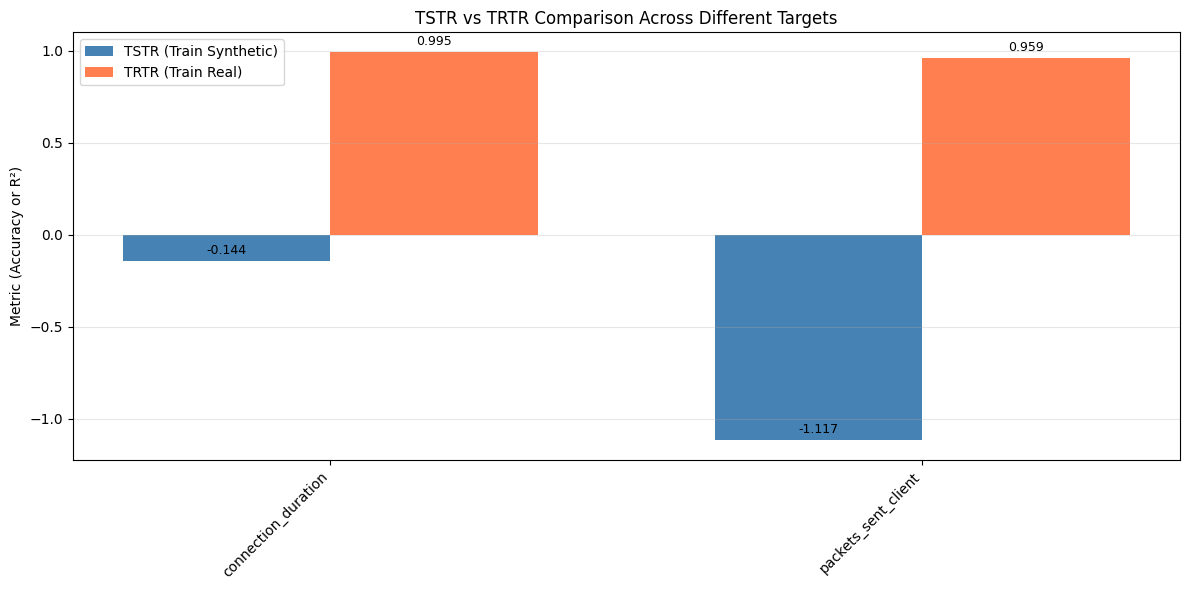

In [39]:
# Visualization: Compare TSTR vs TRTR for each target
if len(all_results) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    targets = [r['target'] for r in all_results]
    tstr_metrics = [r['tstr_metric'] for r in all_results]
    trtr_metrics = [r['trtr_metric'] for r in all_results]
    
    x = np.arange(len(targets))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, tstr_metrics, width, label='TSTR (Train Synthetic)', color='steelblue')
    bars2 = ax.bar(x + width/2, trtr_metrics, width, label='TRTR (Train Real)', color='coral')
    
    ax.set_ylabel('Metric (Accuracy or R²)')
    ax.set_title('TSTR vs TRTR Comparison Across Different Targets')
    ax.set_xticks(x)
    ax.set_xticklabels(targets, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

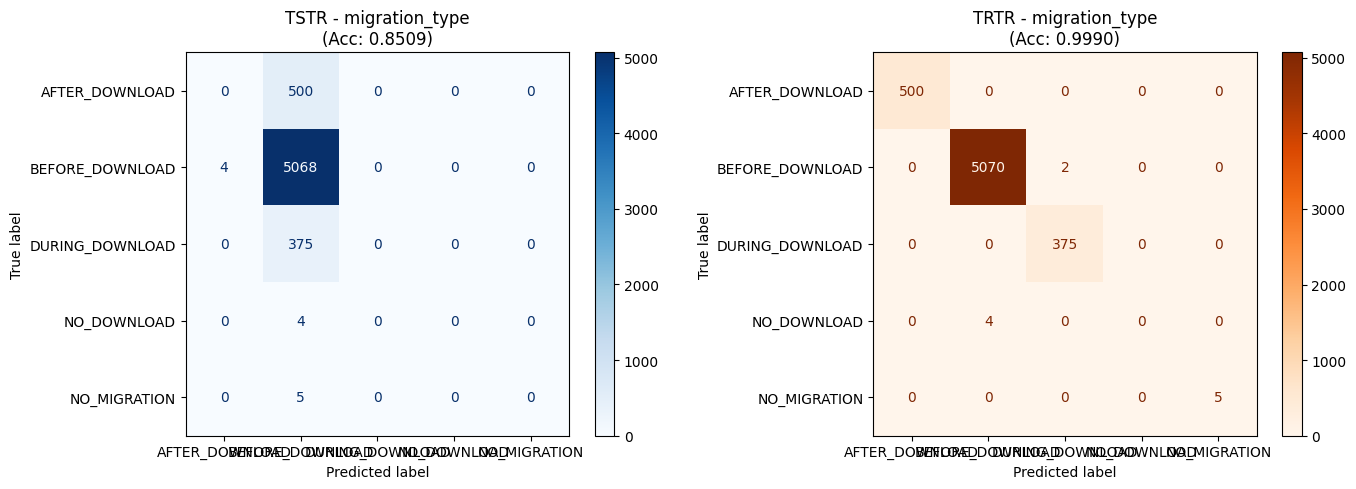

In [28]:
# Confusion matrices for classification targets
classification_results = [r for r in all_results if r['task_type'] == 'classification']

if len(classification_results) > 0:
    n_targets = len(classification_results)
    fig, axes = plt.subplots(n_targets, 2, figsize=(14, 5*n_targets))
    
    if n_targets == 1:
        axes = axes.reshape(1, -1)
    
    for i, r in enumerate(classification_results):
        # TSTR confusion matrix
        cm_tstr = confusion_matrix(r['tstr_labels'], r['tstr_preds'])
        disp_tstr = ConfusionMatrixDisplay(confusion_matrix=cm_tstr, 
                                           display_labels=r['encoder'].classes_ if r['encoder'] else None)
        disp_tstr.plot(ax=axes[i, 0], cmap='Blues', values_format='d')
        axes[i, 0].set_title(f"TSTR - {r['target']}\n(Acc: {r['tstr_metric']:.4f})")
        
        # TRTR confusion matrix
        cm_trtr = confusion_matrix(r['trtr_labels'], r['trtr_preds'])
        disp_trtr = ConfusionMatrixDisplay(confusion_matrix=cm_trtr,
                                           display_labels=r['encoder'].classes_ if r['encoder'] else None)
        disp_trtr.plot(ax=axes[i, 1], cmap='Oranges', values_format='d')
        axes[i, 1].set_title(f"TRTR - {r['target']}\n(Acc: {r['trtr_metric']:.4f})")
    
    plt.tight_layout()
    plt.show()

DIAGNOSING NEGATIVE R² VALUES

--- connection_duration ---
Real data target statistics:
  Mean: 169.2033
  Std:  386.0817
  Min:  -1494.9422
  Max:  1766.9101

TSTR Predictions vs True Labels:
  True labels - Mean: 0.0000, Std: 1.0000
  Predictions  - Mean: -0.3300, Std: 0.0824

  SS_total: 5956.0000
  SS_residual: 6812.7832
  R² = 1 - 6812.7832/5956.0000 = -0.1439

--- packets_sent_client ---
Real data target statistics:
  Mean: 11.4948
  Std:  1.8484
  Min:  1.0000
  Max:  17.0000

TSTR Predictions vs True Labels:
  True labels - Mean: -0.0000, Std: 1.0000
  Predictions  - Mean: -0.0915, Std: 0.8019

  SS_total: 5956.0000
  SS_residual: 12609.2520
  R² = 1 - 12609.2520/5956.0000 = -1.1171


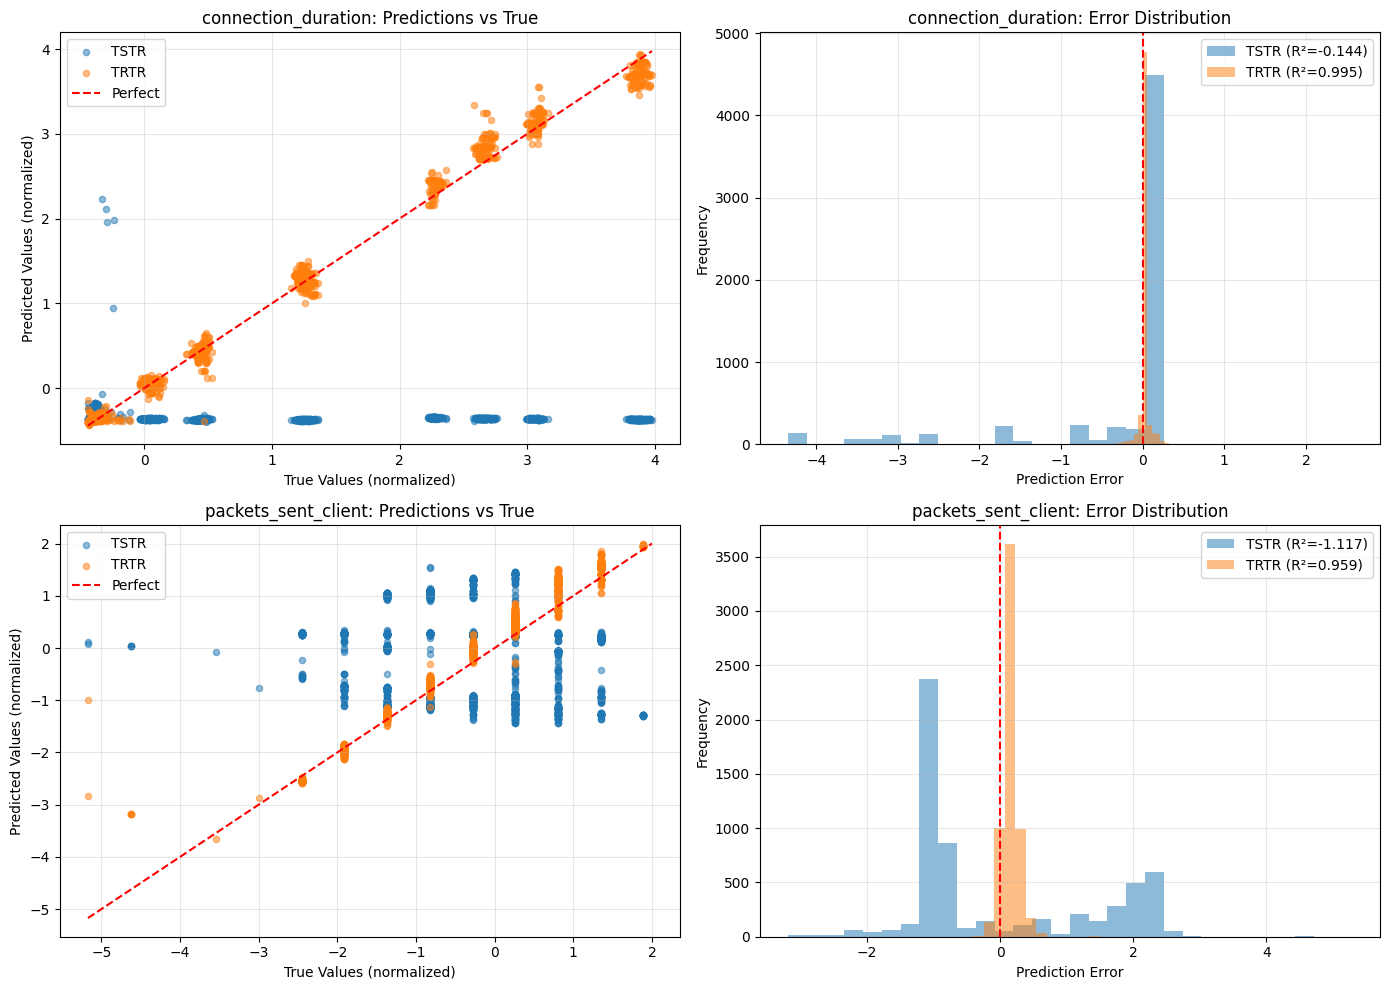

In [40]:
# Diagnose negative R² - Compare target distributions
print("="*60)
print("DIAGNOSING NEGATIVE R² VALUES")
print("="*60)

regression_results = [r for r in all_results if r['task_type'] == 'regression']

for r in regression_results:
    target = r['target']
    print(f"\n--- {target} ---")
    
    # Get target values from high-level data
    real_targets = high_level_df[high_level_df[target].notna()][target]
    
    print(f"Real data target statistics:")
    print(f"  Mean: {real_targets.mean():.4f}")
    print(f"  Std:  {real_targets.std():.4f}")
    print(f"  Min:  {real_targets.min():.4f}")
    print(f"  Max:  {real_targets.max():.4f}")
    
    # Analyze predictions vs labels
    print(f"\nTSTR Predictions vs True Labels:")
    print(f"  True labels - Mean: {np.mean(r['tstr_labels']):.4f}, Std: {np.std(r['tstr_labels']):.4f}")
    print(f"  Predictions  - Mean: {np.mean(r['tstr_preds']):.4f}, Std: {np.std(r['tstr_preds']):.4f}")
    
    # Calculate what "mean prediction" R² would be (always 0 by definition)
    # Negative R² means model is worse than this
    mean_pred = np.mean(r['tstr_labels'])
    ss_tot = np.sum((r['tstr_labels'] - mean_pred)**2)
    ss_res = np.sum((r['tstr_labels'] - r['tstr_preds'])**2)
    print(f"\n  SS_total: {ss_tot:.4f}")
    print(f"  SS_residual: {ss_res:.4f}")
    print(f"  R² = 1 - {ss_res:.4f}/{ss_tot:.4f} = {1 - ss_res/ss_tot:.4f}")

# Visualize prediction distributions
if len(regression_results) > 0:
    fig, axes = plt.subplots(len(regression_results), 2, figsize=(14, 5*len(regression_results)))
    if len(regression_results) == 1:
        axes = axes.reshape(1, -1)
    
    for i, r in enumerate(regression_results):
        # Scatter plot: predictions vs true
        axes[i, 0].scatter(r['tstr_labels'], r['tstr_preds'], alpha=0.5, s=20, label='TSTR')
        axes[i, 0].scatter(r['trtr_labels'], r['trtr_preds'], alpha=0.5, s=20, label='TRTR')
        
        # Add perfect prediction line
        all_vals = np.concatenate([r['tstr_labels'], r['tstr_preds'], r['trtr_labels'], r['trtr_preds']])
        min_val, max_val = all_vals.min(), all_vals.max()
        axes[i, 0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect')
        axes[i, 0].set_xlabel('True Values (normalized)')
        axes[i, 0].set_ylabel('Predicted Values (normalized)')
        axes[i, 0].set_title(f'{r["target"]}: Predictions vs True')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)
        
        # Histogram of errors
        tstr_errors = r['tstr_preds'] - r['tstr_labels']
        trtr_errors = r['trtr_preds'] - r['trtr_labels']
        axes[i, 1].hist(tstr_errors, bins=30, alpha=0.5, label=f'TSTR (R²={r["tstr_metric"]:.3f})')
        axes[i, 1].hist(trtr_errors, bins=30, alpha=0.5, label=f'TRTR (R²={r["trtr_metric"]:.3f})')
        axes[i, 1].axvline(0, color='r', linestyle='--')
        axes[i, 1].set_xlabel('Prediction Error')
        axes[i, 1].set_ylabel('Frequency')
        axes[i, 1].set_title(f'{r["target"]}: Error Distribution')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Summary

This notebook evaluates **Machine Learning Utility** for low-level synthetic network data using the **Train Synthetic Test Real (TSTR)** methodology.

### Workflow:
1. **Data Loading**: Load low-level packet sequences and high-level features with target labels
2. **Dataset Class**: `LowLevelSequenceDataset` handles variable-length sequences with proper scaling
3. **Model**: Bidirectional LSTM with attention for sequence classification/regression
4. **TSTR Evaluation**: Compare models trained on synthetic vs real data

### Targets Evaluated:
- **Classification**: `implementation`, `migration_type`, `connection_close_type`
- **Regression** (optional): `handshake_duration`, `connection_duration`

### Metrics:
- **TSTR**: Train on synthetic data, test on real data
- **TRTR**: Train on real data, test on real data (baseline)
- **Ratio (TSTR/TRTR)**: Closer to 1.0 indicates better synthetic data quality